In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
import os

# Create folder for all experiment outputs
os.makedirs("Experiment_4_Plots", exist_ok=True)

def save_plot(filename):
    plt.savefig(
        f"Experiment_4_Plots/{filename}.eps",
        format="eps",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"Experiment_4_Plots/{filename}.png",
        format="png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Subsample to keep total runtime under ~30 min
N_TRAIN, N_TEST = 4000, 800
X_train, y_train = X_train[:N_TRAIN], y_train[:N_TRAIN]
X_test, y_test = X_test[:N_TEST], y_test[:N_TEST]

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)
print("Image Size      :", X_train.shape[1:])
print("Number of Classes:", len(np.unique(y_train)))

class_names = ["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2157s 13us/step
Training Images : (4000, 32, 32, 3)
Training Labels : (4000, 1)
Testing Images  : (800, 32, 32, 3)
Testing Labels  : (800, 1)
Image Size      : (32, 32, 3)
Number of Classes: 10


In [5]:
# Normalize

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

# One hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Labels:", y_train_cat.shape)
print("Testing Labels :", y_test_cat.shape)

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
Training Labels: (4000, 10)
Testing Labels : (800, 10)


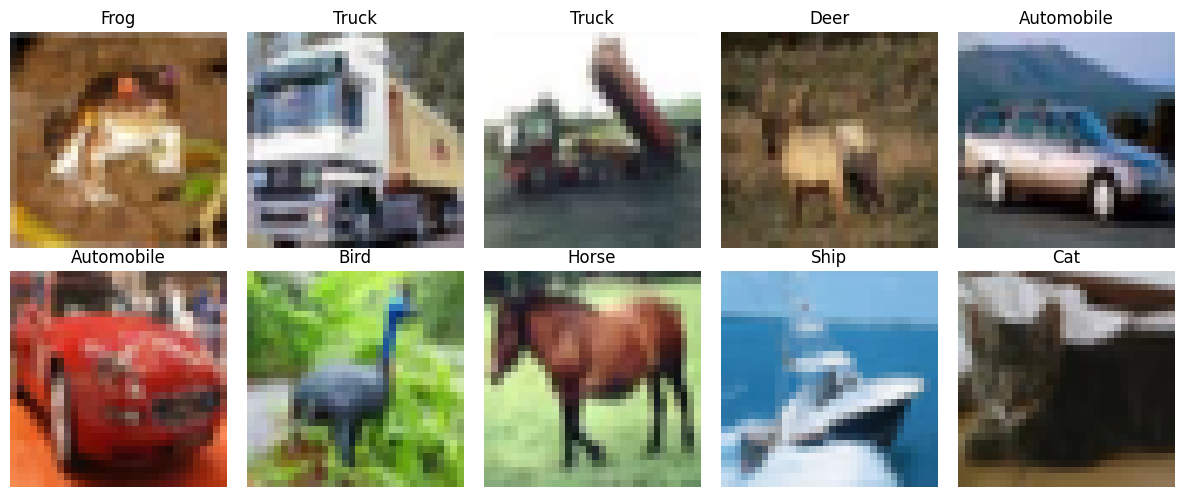

In [6]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("01_Sample_CIFAR10_Images.eps")
plt.show()

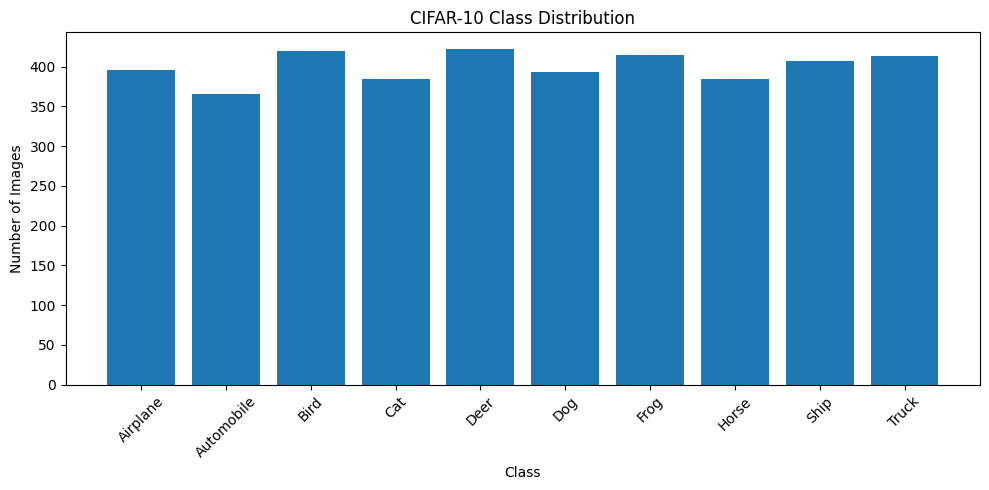

In [7]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts.flatten())

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("02_ClassDist.eps")
plt.show()

In [8]:
IMG_SIZE = 96
BATCH_SIZE = 32

# Create TensorFlow datasets WITHOUT resizing the entire dataset at once
train_tl = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_cat)
)

test_tl = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test_cat)
)

# Resize only each batch during training
train_tl = (
    train_tl
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(
        lambda x, y: (tf.image.resize(x, (IMG_SIZE, IMG_SIZE)), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)

test_tl = (
    test_tl
    .batch(BATCH_SIZE)
    .map(
        lambda x, y: (tf.image.resize(x, (IMG_SIZE, IMG_SIZE)), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)

print("Transfer learning datasets created successfully.")
print("Images will be resized batch-by-batch to:", IMG_SIZE, "x", IMG_SIZE)

Transfer learning datasets created successfully.
Images will be resized batch-by-batch to: 96 x 96


In [9]:
def resize_dataset(images, labels):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(
        lambda x, y: (tf.image.resize(x, (224, 224)), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [10]:
def build_transfer_model(base_model, dense_units=128, learning_rate=0.001):

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

vgg_model = build_transfer_model(vgg_base)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
start_time = time.time()

history_vgg = vgg_model.fit(
    train_tl,
    validation_data=test_tl,
    epochs=5,
    verbose=1
)

vgg_training_time = time.time() - start_time

print("Training Time:", vgg_training_time, "seconds")

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.3638 - loss: 1.8965 - val_accuracy: 0.4338 - val_loss: 1.6188
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.5340 - loss: 1.4346 - val_accuracy: 0.5325 - val_loss: 1.3659
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.5778 - loss: 1.2557 - val_accuracy: 0.5425 - val_loss: 1.2794
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.6133 - loss: 1.1383 - val_accuracy: 0.5788 - val_loss: 1.2002
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 348s 3s/step - accuracy: 0.6407 - loss: 1.0695 - val_accuracy: 0.5888 - val_loss: 1.1614
Training Time: 1716.2151918411255 seconds


In [13]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

resnet_model = build_transfer_model(resnet_base)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
start_time = time.time()

# history_resnet = resnet_model.fit(
#     train_tl,
#     y_train_cat,
#     validation_split=0.1,
#     epochs=3,
#     batch_size=32,
#     verbose=1
# )


history_resnet = resnet_model.fit(train_tl, validation_data=test_tl, epochs=3, verbose=1)

resnet_training_time = time.time() - start_time

print("Training Time:", resnet_training_time, "seconds")

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 101s 770ms/step - accuracy: 0.1268 - loss: 2.3013 - val_accuracy: 0.1388 - val_loss: 2.2560
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 135s 715ms/step - accuracy: 0.1735 - loss: 2.2382 - val_accuracy: 0.2288 - val_loss: 2.2030
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 148s 762ms/step - accuracy: 0.1978 - loss: 2.1836 - val_accuracy: 0.2125 - val_loss: 2.1614
Training Time: 430.4995987415314 seconds


In [15]:
mobile_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

mobile_model = build_transfer_model(mobile_base)

mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
start_time = time.time()

# history_mobile = mobile_model.fit(
#     train_tl,
#     y_train_cat,
#     validation_split=0.1,
#     epochs=3,
#     batch_size=32,
#     verbose=1
# )


history_mobile = mobile_model.fit(train_tl, validation_data=test_tl, epochs=3, verbose=1)

mobile_training_time = time.time() - start_time

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.6348 - loss: 1.0760 - val_accuracy: 0.7113 - val_loss: 0.8243
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.7847 - loss: 0.6131 - val_accuracy: 0.7563 - val_loss: 0.7103
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.8422 - loss: 0.4684 - val_accuracy: 0.7425 - val_loss: 0.7512


In [17]:
def fine_tune_model(model, base_model, epochs=2, learning_rate=0.0001):
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    start_time = time.time()
    history = model.fit(train_tl, validation_data=test_tl, epochs=epochs, verbose=1)
    training_time = time.time() - start_time
    return history, training_time

In [18]:
history_vgg_ft, vgg_ft_time = fine_tune_model(
    vgg_model,
    vgg_base,
    epochs=2,
    learning_rate=0.0001
)

Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 1120s 9s/step - accuracy: 0.5700 - loss: 1.2384 - val_accuracy: 0.6562 - val_loss: 0.9849
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 1110s 9s/step - accuracy: 0.7947 - loss: 0.5889 - val_accuracy: 0.7150 - val_loss: 0.7957


In [19]:
history_resnet_ft, resnet_ft_time = fine_tune_model(
    resnet_model,
    resnet_base,
    epochs=2,
    learning_rate=0.0001
)



Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.3080 - loss: 1.8997 - val_accuracy: 0.2200 - val_loss: 2.1812
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.3803 - loss: 1.6935 - val_accuracy: 0.2113 - val_loss: 2.1149


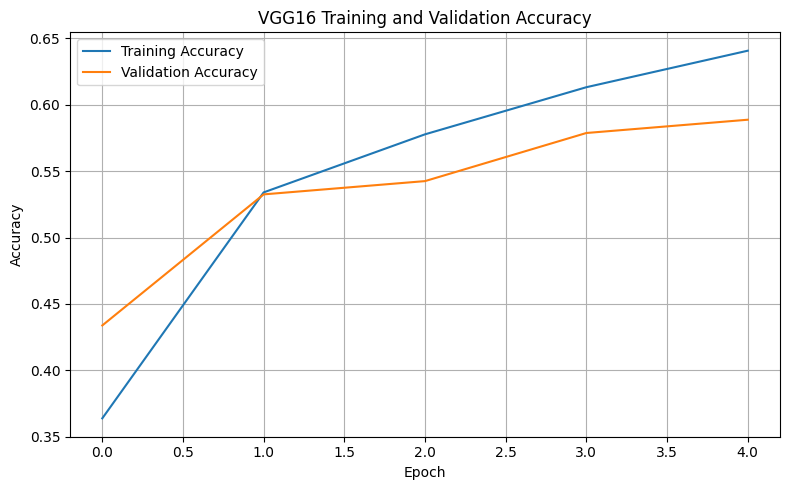

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_vgg.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("03_Training_Accuracy.eps")
plt.show()

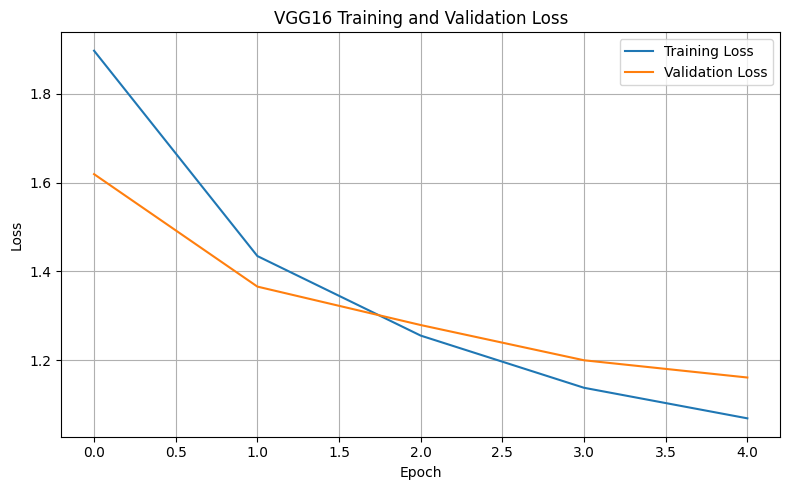

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_vgg.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("03_Training_Loss.eps")
plt.show()

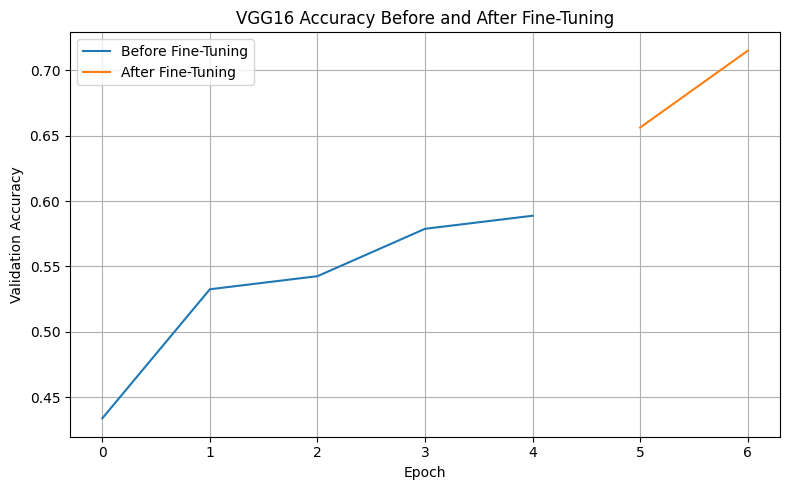

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg.history["val_accuracy"],
    label="Before Fine-Tuning"
)

plt.plot(
    range(
        len(history_vgg.history["val_accuracy"]),
        len(history_vgg.history["val_accuracy"]) +
        len(history_vgg_ft.history["val_accuracy"])
    ),
    history_vgg_ft.history["val_accuracy"],
    label="After Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("VGG16 Accuracy Before and After Fine-Tuning")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("04_Fine-Tuning_Accuracy_Comparison.eps")
plt.show()

In [23]:
def evaluate_model(model, X_test_data, y_test_data, model_name):

    start_time = time.time()

    loss, accuracy = model.evaluate(
        X_test_data,
        y_test_data,
        verbose=0
    )

    predictions = model.predict(
        X_test_data,
        verbose=0
    )

    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y_test_data, axis=1)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    evaluation_time = time.time() - start_time

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Test Loss    :", round(loss, 4))
    print("Accuracy     :", round(accuracy, 4))
    print("Precision    :", round(precision, 4))
    print("Recall       :", round(recall, 4))
    print("F1-score     :", round(f1, 4))

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Loss": loss,
        "Predictions": y_pred,
        "True Labels": y_true
    }

In [34]:
def evaluate_transfer_model(model, dataset, model_name):

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(images, verbose=0)

        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(model_name, "Performance")
    print("=" * 50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\nClassification Report")
    print("=" * 50)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    return {
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "True Labels": y_true,
    "Predictions": y_pred
}

In [35]:
vgg_results = evaluate_transfer_model(
    vgg_model,
    test_tl,
    "VGG16"
)


VGG16 Performance
Accuracy : 0.715
Precision: 0.7580286619950811
Recall   : 0.715
F1-score : 0.7085489141326328

Classification Report
              precision    recall  f1-score   support

    Airplane       0.59      0.68      0.63        80
  Automobile       0.93      0.86      0.90        66
        Bird       0.94      0.41      0.57        81
         Cat       0.69      0.49      0.57        78
        Deer       0.51      0.75      0.61        71
         Dog       0.70      0.79      0.74        75
        Frog       0.74      0.87      0.80        95
       Horse       0.97      0.47      0.64        78
        Ship       0.62      0.95      0.75        84
       Truck       0.88      0.85      0.86        92

    accuracy                           0.71       800
   macro avg       0.76      0.71      0.71       800
weighted avg       0.76      0.71      0.71       800



In [30]:
resnet_results = evaluate_transfer_model(
    resnet_model,
    test_tl,
    "ResNet50"
)


ResNet50 Performance
Accuracy : 0.21125
Precision: 0.1840809492231906
Recall   : 0.21125
F1-score : 0.1318143426382491

Classification Report
              precision    recall  f1-score   support

    Airplane       0.43      0.04      0.07        80
  Automobile       0.37      0.29      0.32        66
        Bird       0.33      0.01      0.02        81
         Cat       0.00      0.00      0.00        78
        Deer       0.00      0.00      0.00        71
         Dog       0.38      0.29      0.33        75
        Frog       0.00      0.00      0.00        95
       Horse       0.00      0.00      0.00        78
        Ship       0.16      0.81      0.27        84
       Truck       0.22      0.61      0.32        92

    accuracy                           0.21       800
   macro avg       0.19      0.20      0.13       800
weighted avg       0.18      0.21      0.13       800



In [31]:
mobile_results = evaluate_transfer_model(
    mobile_model,
    test_tl,
    "MobileNetV2"
)


MobileNetV2 Performance
Accuracy : 0.7425
Precision: 0.7702281274429096
Recall   : 0.7425
F1-score : 0.7410432802159421

Classification Report
              precision    recall  f1-score   support

    Airplane       0.75      0.74      0.74        80
  Automobile       0.90      0.79      0.84        66
        Bird       0.65      0.70      0.67        81
         Cat       0.79      0.40      0.53        78
        Deer       0.76      0.68      0.72        71
         Dog       0.48      0.83      0.60        75
        Frog       0.83      0.81      0.82        95
       Horse       0.90      0.60      0.72        78
        Ship       0.76      0.93      0.84        84
       Truck       0.86      0.90      0.88        92

    accuracy                           0.74       800
   macro avg       0.77      0.74      0.74       800
weighted avg       0.77      0.74      0.74       800



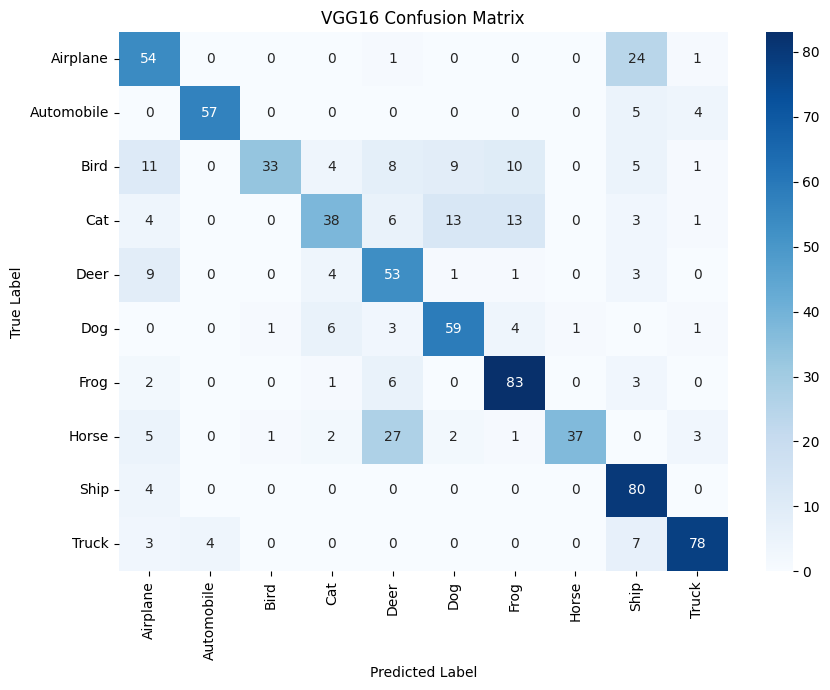

In [36]:
cm = confusion_matrix(
    vgg_results["True Labels"],
    vgg_results["Predictions"]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("VGG16 Confusion Matrix")

plt.tight_layout()
plt.savefig("05_Confusion_Matrix.eps")
plt.show()

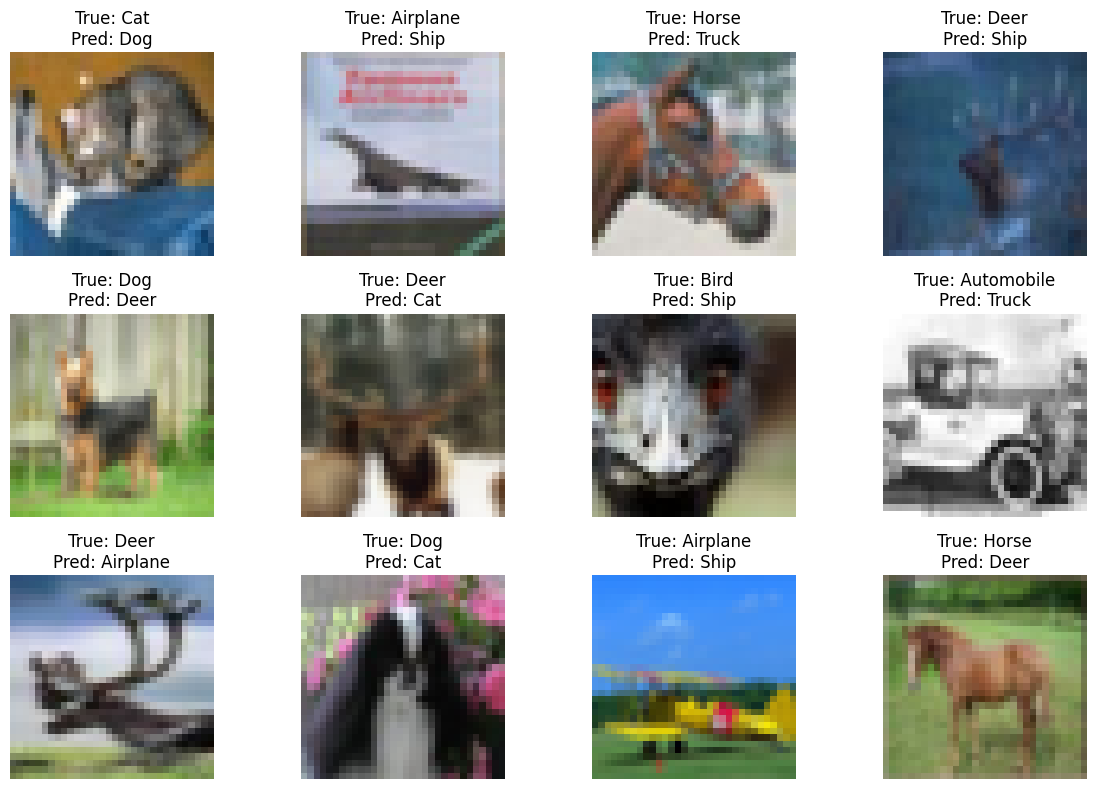

In [37]:
incorrect = np.where(
    vgg_results["Predictions"] !=
    vgg_results["True Labels"]
)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(incorrect[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx])

    true_label = class_names[
        vgg_results["True Labels"][idx]
    ]

    predicted_label = class_names[
        vgg_results["Predictions"][idx]
    ]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig("06_Misclassified_Images.eps")
plt.show()

In [38]:
performance_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)",
        "Total Parameters"
    ],

    "Value": [
        history_vgg.history["accuracy"][-1],
        vgg_results["Accuracy"],
        vgg_results["Precision"],
        vgg_results["Recall"],
        vgg_results["F1-score"],
        vgg_training_time,
        vgg_model.count_params()
    ]
})

display(performance_table)

,Metric,Value
0,Training Accuracy,6.407500e-01
1,Testing Accuracy,7.150000e-01
2,Precision,7.580287e-01
3,Recall,7.150000e-01
4,F1-score,7.085489e-01
5,Training Time (s),1.716215e+03
6,Total Parameters,1.478164e+07


In [39]:
before_ft_accuracy = max(
    history_vgg.history["val_accuracy"]
)

after_ft_accuracy = max(
    history_vgg_ft.history["val_accuracy"]
)

fine_tuning_table = pd.DataFrame({
    "Stage": [
        "Before Fine-Tuning",
        "After Fine-Tuning"
    ],

    "Validation Accuracy": [
        before_ft_accuracy,
        after_ft_accuracy
    ]
})

display(fine_tuning_table)

,Stage,Validation Accuracy
0,Before Fine-Tuning,0.58875
1,After Fine-Tuning,0.71500


In [40]:
def build_lenet():

    model = models.Sequential([

        layers.Conv2D(
            6,
            (5, 5),
            activation="tanh",
            input_shape=(32, 32, 3)
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            16,
            (5, 5),
            activation="tanh"
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            120,
            activation="tanh"
        ),

        layers.Dense(
            84,
            activation="tanh"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [42]:
lenet = build_lenet()

start = time.time()

history_lenet = lenet.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

lenet_time = time.time() - start

lenet_results = evaluate_model(
    lenet,
    X_test,
    y_test_cat,
    "LeNet-5"
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2208 - loss: 2.1306 - val_accuracy: 0.3200 - val_loss: 1.9852
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3217 - loss: 1.9095 - val_accuracy: 0.3500 - val_loss: 1.8837
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3600 - loss: 1.8146 - val_accuracy: 0.3475 - val_loss: 1.8759
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3742 - loss: 1.7649 - val_accuracy: 0.3200 - val_loss: 1.8890
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4011 - loss: 1.7006 - val_accuracy: 0.3475 - val_loss: 1.7975
LeNet-5
Test Loss    : 1.8139
Accuracy     : 0.3713
Precision    : 0.3497
Recall       : 0.3713
F1-score     : 0.3497

Classification Report
              precision    recall  f1-score   support

    Airplane       0.41      0.38      0.39        80
  Automobile       0.46      0.50      0.48        66
        Bird       0.25      0.16      0.19        81
         Cat

In [41]:
def build_alexnet():

    model = models.Sequential([

        layers.Conv2D(
            96,
            (3, 3),
            padding="same",
            activation="relu",
            input_shape=(32, 32, 3)
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            256,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            384,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            384,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            4096,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            4096,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [43]:
alexnet = build_alexnet()

start = time.time()

history_alexnet = alexnet.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

alexnet_time = time.time() - start

alexnet_results = evaluate_model(
    alexnet,
    X_test,
    y_test_cat,
    "AlexNet"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.0958 - loss: 2.3294 - val_accuracy: 0.0975 - val_loss: 2.3034
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.0967 - loss: 2.3040 - val_accuracy: 0.0800 - val_loss: 2.3032
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.1081 - loss: 2.3035 - val_accuracy: 0.0800 - val_loss: 2.3003
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.0956 - loss: 2.3041 - val_accuracy: 0.1200 - val_loss: 2.3019
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.0978 - loss: 2.3034 - val_accuracy: 0.1200 - val_loss: 2.3022
AlexNet
Test Loss    : 2.3024
Accuracy     : 0.0887
Precision    : 0.0079
Recall       : 0.0887
F1-score     : 0.0145

Classification Report
              precision    recall  f1-score   support

    Airplane       0.00      0.00      0.00        80
  Automobile       0.00      0.00      0.00        66
        Bird       0.00      0.00      0.00        81
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [44]:
inception_base = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

inception_model = build_transfer_model(
    inception_base,
    dense_units=128
)

inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [46]:
start = time.time()

history_inception = inception_model.fit(
    train_tl,
    epochs=3,
    verbose=1
)

inception_time = time.time() - start

print("Inception Training Time:", inception_time, "seconds")

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 291ms/step - accuracy: 0.4635 - loss: 1.5971
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 291ms/step - accuracy: 0.6615 - loss: 0.9825
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 290ms/step - accuracy: 0.7495 - loss: 0.7365
Inception Training Time: 126.52952122688293 seconds


In [48]:
inception_results = evaluate_transfer_model(
    inception_model,
    test_tl,
    "GoogleNet/Inception"
)


GoogleNet/Inception Performance
Accuracy : 0.58875
Precision: 0.6069106754036564
Recall   : 0.58875
F1-score : 0.5905706695813137

Classification Report
              precision    recall  f1-score   support

    Airplane       0.63      0.40      0.49        80
  Automobile       0.64      0.74      0.69        66
        Bird       0.55      0.48      0.51        81
         Cat       0.44      0.53      0.48        78
        Deer       0.41      0.54      0.47        71
         Dog       0.48      0.65      0.55        75
        Frog       0.73      0.60      0.66        95
       Horse       0.65      0.60      0.63        78
        Ship       0.76      0.61      0.68        84
       Truck       0.71      0.74      0.72        92

    accuracy                           0.59       800
   macro avg       0.60      0.59      0.59       800
weighted avg       0.61      0.59      0.59       800



In [49]:
architecture_comparison = pd.DataFrame({

    "Model": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet/Inception",
        "ResNet50"
    ],

    "Parameters": [
        lenet.count_params(),
        alexnet.count_params(),
        vgg_model.count_params(),
        inception_model.count_params(),
        resnet_model.count_params()
    ],

    "Accuracy (%)": [
        lenet_results["Accuracy"] * 100,
        alexnet_results["Accuracy"] * 100,
        vgg_results["Accuracy"] * 100,
        inception_results["Accuracy"] * 100,
        resnet_results["Accuracy"] * 100
    ],

    "Training Time (s)": [
        lenet_time,
        alexnet_time,
        vgg_training_time,
        inception_time,
        resnet_training_time
    ]
})

display(architecture_comparison)

,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,62006,37.125,9.491083
1,AlexNet,36925322,8.875,694.646302
2,VGG16,14781642,71.500,1716.215192
3,GoogleNet/Inception,22066346,58.875,126.529521
4,ResNet50,23851274,21.125,430.499599


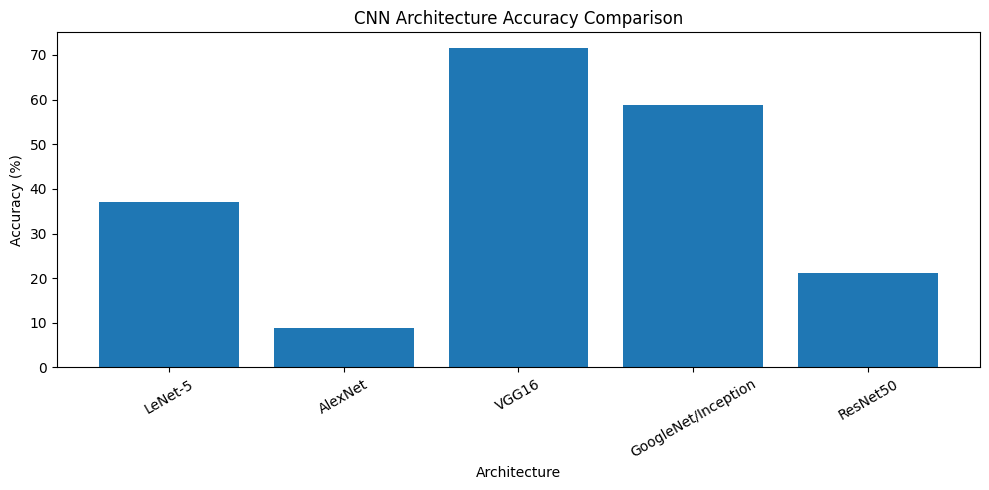

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(
    architecture_comparison["Model"],
    architecture_comparison["Accuracy (%)"]
)

plt.xlabel("Architecture")
plt.ylabel("Accuracy (%)")
plt.title("CNN Architecture Accuracy Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("07_Architecture_Accuracy_Comparison.eps")
plt.show()

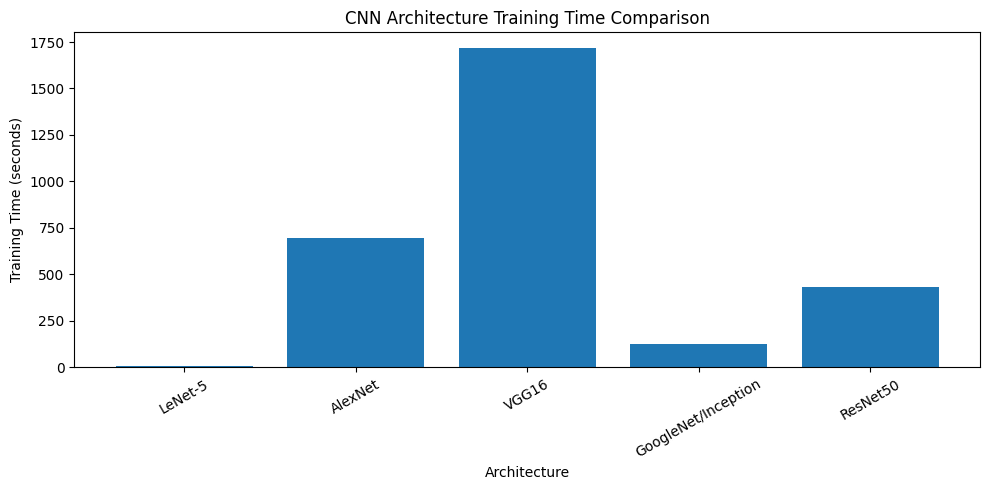

In [51]:
plt.figure(figsize=(10, 5))

plt.bar(
    architecture_comparison["Model"],
    architecture_comparison["Training Time (s)"]
)

plt.xlabel("Architecture")
plt.ylabel("Training Time (seconds)")
plt.title("CNN Architecture Training Time Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("08_Architecture_TrainingTime_Comparison.eps")
plt.show()

In [52]:
hyperparameter_results = []

configs = [
    {"learning_rate": 0.001, "batch_size": 32, "epochs": 2, "optimizer": "adam", "dense_units": 128},
    {"learning_rate": 0.001, "batch_size": 32, "epochs": 2, "optimizer": "sgd",  "dense_units": 128},
]

In [61]:
def run_hyperparameter_experiment(config):

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(96, 96, 3)
    )

    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            config["dense_units"],
            activation="relu"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Optimizer
    if config["optimizer"].lower() == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        )

    else:

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=config["learning_rate"]
        )

    # Compile
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # --------------------------------------------------
    # Create training and validation datasets
    # --------------------------------------------------

    all_data = train_tl.unbatch()

    validation_data = all_data.take(5000)
    training_data = all_data.skip(5000)

    # Apply selected batch size
    training_data = training_data.batch(
        config["batch_size"]
    )

    validation_data = validation_data.batch(
        config["batch_size"]
    )

    # Repeat so data is available for every epoch
    training_data = training_data.repeat()
    validation_data = validation_data.repeat()

    # Number of steps
    train_steps = 45000 // config["batch_size"]

    val_steps = 5000 // config["batch_size"]

    # --------------------------------------------------
    # Training
    # --------------------------------------------------

    start = time.time()

    history = model.fit(
        training_data,
        validation_data=validation_data,
        steps_per_epoch=train_steps,
        validation_steps=val_steps,
        epochs=config["epochs"],
        verbose=0
    )

    training_time = time.time() - start

    # --------------------------------------------------
    # Testing
    # --------------------------------------------------

    test_loss, test_accuracy = model.evaluate(
        test_tl,
        verbose=0
    )

    # --------------------------------------------------
    # Best validation accuracy
    # --------------------------------------------------

    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    result = {
        **config,
        "test_accuracy": test_accuracy,
        "best_val_accuracy": best_val_accuracy,
        "training_time": training_time
    }

    # Free memory
    del model
    tf.keras.backend.clear_session()

    return result

In [62]:
for config in configs:

    print("Running:", config)

    result = run_hyperparameter_experiment(config)

    hyperparameter_results.append(result)


hyperparameter_df = pd.DataFrame(
    hyperparameter_results
)

display(hyperparameter_df)

Running: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 2, 'optimizer': 'adam', 'dense_units': 128}
Running: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 2, 'optimizer': 'sgd', 'dense_units': 128}


,learning_rate,batch_size,epochs,optimizer,dense_units,test_accuracy,best_val_accuracy,training_time
0,0.001,32,2,adam,128,0.08625,0.080128,676.123385
1,0.001,32,2,sgd,128,0.12000,0.134215,765.509181


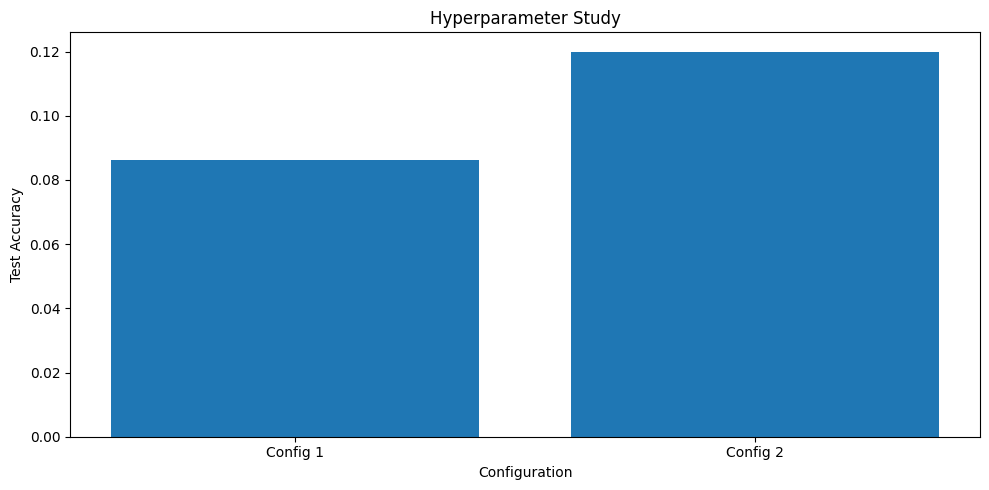

In [63]:
plt.figure(figsize=(10, 5))

plt.bar(
    range(len(hyperparameter_df)),
    hyperparameter_df["test_accuracy"]
)

plt.xlabel("Configuration")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Study")

plt.xticks(
    range(len(hyperparameter_df)),
    [
        f"Config {i+1}"
        for i in range(len(hyperparameter_df))
    ]
)

plt.tight_layout()
plt.savefig("09_Hyperparameter_Accuracy_Plot.eps")
plt.show()

In [64]:
optimizer_comparison = hyperparameter_df[
    hyperparameter_df["optimizer"].isin(
        ["adam", "sgd"]
    )
]

display(
    optimizer_comparison[
        [
            "optimizer",
            "learning_rate",
            "test_accuracy",
            "training_time"
        ]
    ]
)

,optimizer,learning_rate,test_accuracy,training_time
0,adam,0.001,0.08625,676.123385
1,sgd,0.001,0.12000,765.509181


In [65]:
frozen_accuracy = max(
    history_vgg.history["val_accuracy"]
)

fine_tuned_accuracy = max(
    history_vgg_ft.history["val_accuracy"]
)

frozen_vs_finetuned = pd.DataFrame({
    "Training Strategy": [
        "Frozen Convolutional Base",
        "Fine-Tuned Model"
    ],

    "Validation Accuracy": [
        frozen_accuracy,
        fine_tuned_accuracy
    ]
})

display(frozen_vs_finetuned)

,Training Strategy,Validation Accuracy
0,Frozen Convolutional Base,0.58875
1,Fine-Tuned Model,0.71500


In [66]:
report_dict = classification_report(
    vgg_results["True Labels"],
    vgg_results["Predictions"],
    target_names=class_names,
    output_dict=True
)

classification_table = pd.DataFrame(
    report_dict
).transpose()

display(classification_table)

,precision,recall,f1-score,support
Airplane,0.586957,0.675000,0.627907,80.000
Automobile,0.934426,0.863636,0.897638,66.000
Bird,0.942857,0.407407,0.568966,81.000
Cat,0.690909,0.487179,0.571429,78.000
Deer,0.509615,0.746479,0.605714,71.000
Dog,0.702381,0.786667,0.742138,75.000
Frog,0.741071,0.873684,0.801932,95.000
Horse,0.973684,0.474359,0.637931,78.000
Ship,0.615385,0.952381,0.747664,84.000
Truck,0.876404,0.847826,0.861878,92.000


In [67]:
classification_table.to_csv(
    "classification_report.csv"
)

In [68]:
final_results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)",
        "Total Parameters"
    ],

    "Value": [
        history_vgg.history["accuracy"][-1],
        vgg_results["Accuracy"],
        vgg_results["Precision"],
        vgg_results["Recall"],
        vgg_results["F1-score"],
        vgg_training_time,
        vgg_model.count_params()
    ]
})

display(final_results)

,Metric,Value
0,Training Accuracy,6.407500e-01
1,Testing Accuracy,7.150000e-01
2,Precision,7.580287e-01
3,Recall,7.150000e-01
4,F1-score,7.085489e-01
5,Training Time (s),1.716215e+03
6,Total Parameters,1.478164e+07


In [69]:
import shutil
from google.colab import files

# Create ZIP file containing all plots
shutil.make_archive(
    "Experiment_4_Plots",
    "zip",
    "Experiment_4_Plots"
)

# Download the ZIP file
files.download("Experiment_4_Plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>